<a href="https://colab.research.google.com/github/bjrrnet/argkille/blob/main/TAM400_G7_Projekt_Arbete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Import Data

###Column description

*   Timestamp                      : A snapshot for when the value was taken.
*   Machine_ID                     : The ID of the measured Machine
*   Operation_Mode                 : Can be Active, Idle, Maintinance
*   Temperature_C                  : Measured temperature of the selected machine
*   Vibration_Hz                   : Measured Machine vibrations of the selected machine
*   Power_Consumption_kW           : Measured Power consumption of the selected machine
*   Network_Latency_ms             :
*   Packet_Loss_%                  :
*   Quality_Control_Defect_Rate_%  : Total products produced that where defective
*   Production_Speed_units_per_hr  : Output
*   Predictive_Maintenance_Score   : High=good, low=bad (0-1)
*   Error_Rate_%                   :
*   Efficiency_Status              :


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import sys
from packaging import version
import sklearn

# Check versions
assert sys.version_info >= (3, 7)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

from pathlib import Path
import kagglehub  # Replaces tarfile and urllib for downloading from Kaggle

def load_manufacturing_data():
    """
    Downloads the Intelligent Manufacturing dataset using kagglehub
    and returns it as a pandas DataFrame.
    """
    # Download the latest version of the dataset using kagglehub
    print("Downloading dataset from Kaggle...")
    path = kagglehub.dataset_download("ziya07/intelligent-manufacturing-dataset")
    print("Path to dataset files:", path)

    # kagglehub returns a directory. We need to find the CSV file inside it.
    dataset_dir = Path(path)
    csv_files = list(dataset_dir.glob("*.csv"))

    # Ensure a CSV file was actually found
    if not csv_files:
        raise FileNotFoundError(f"No CSV files were found in the downloaded dataset directory: {path}")

    # If there are multiple CSVs, this grabs the first one.
    # (Adjust the index if the dataset has multiple files and you need a specific one).
    target_csv = csv_files[0]
    print(f"Loading file: {target_csv.name}")

    # Load the CSV file into a pandas DataFrame and return it
    return pd.read_csv(target_csv)

# Call the function to load the data
manufacturing_data = load_manufacturing_data()

manufacturing_data.head()


100%|██████████| 8.49M/8.49M [00:00<00:00, 172MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ziya07/intelligent-manufacturing-dataset/versions/1
Loading file: manufacturing_6G_dataset.csv


,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low


In [6]:

manufacturing_data.describe()

,Machine_ID,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,25.499330,60.041458,2.549959,5.745929,25.555620,2.493418,5.008806,275.916324,0.499385,7.504100
std,14.389439,17.323238,1.414127,2.451271,14.120758,1.443273,2.883666,130.096892,0.288814,4.335896
min,1.000000,30.000138,0.100011,1.500183,1.000025,0.000026,0.000449,50.000375,0.000003,0.000112
25%,13.000000,45.031596,1.323214,3.627318,13.355118,1.245026,2.521591,162.873618,0.248166,3.750148
50%,25.000000,60.033597,2.549441,5.755460,25.536079,2.487667,5.003569,276.648922,0.499209,7.504145
75%,38.000000,74.967217,3.776459,7.860267,37.796372,3.741252,7.506127,388.812761,0.748810,11.273189
max,50.000000,89.998979,4.999974,9.999889,49.999917,4.999975,9.999900,499.996768,0.999978,14.999869


##2. Explore data

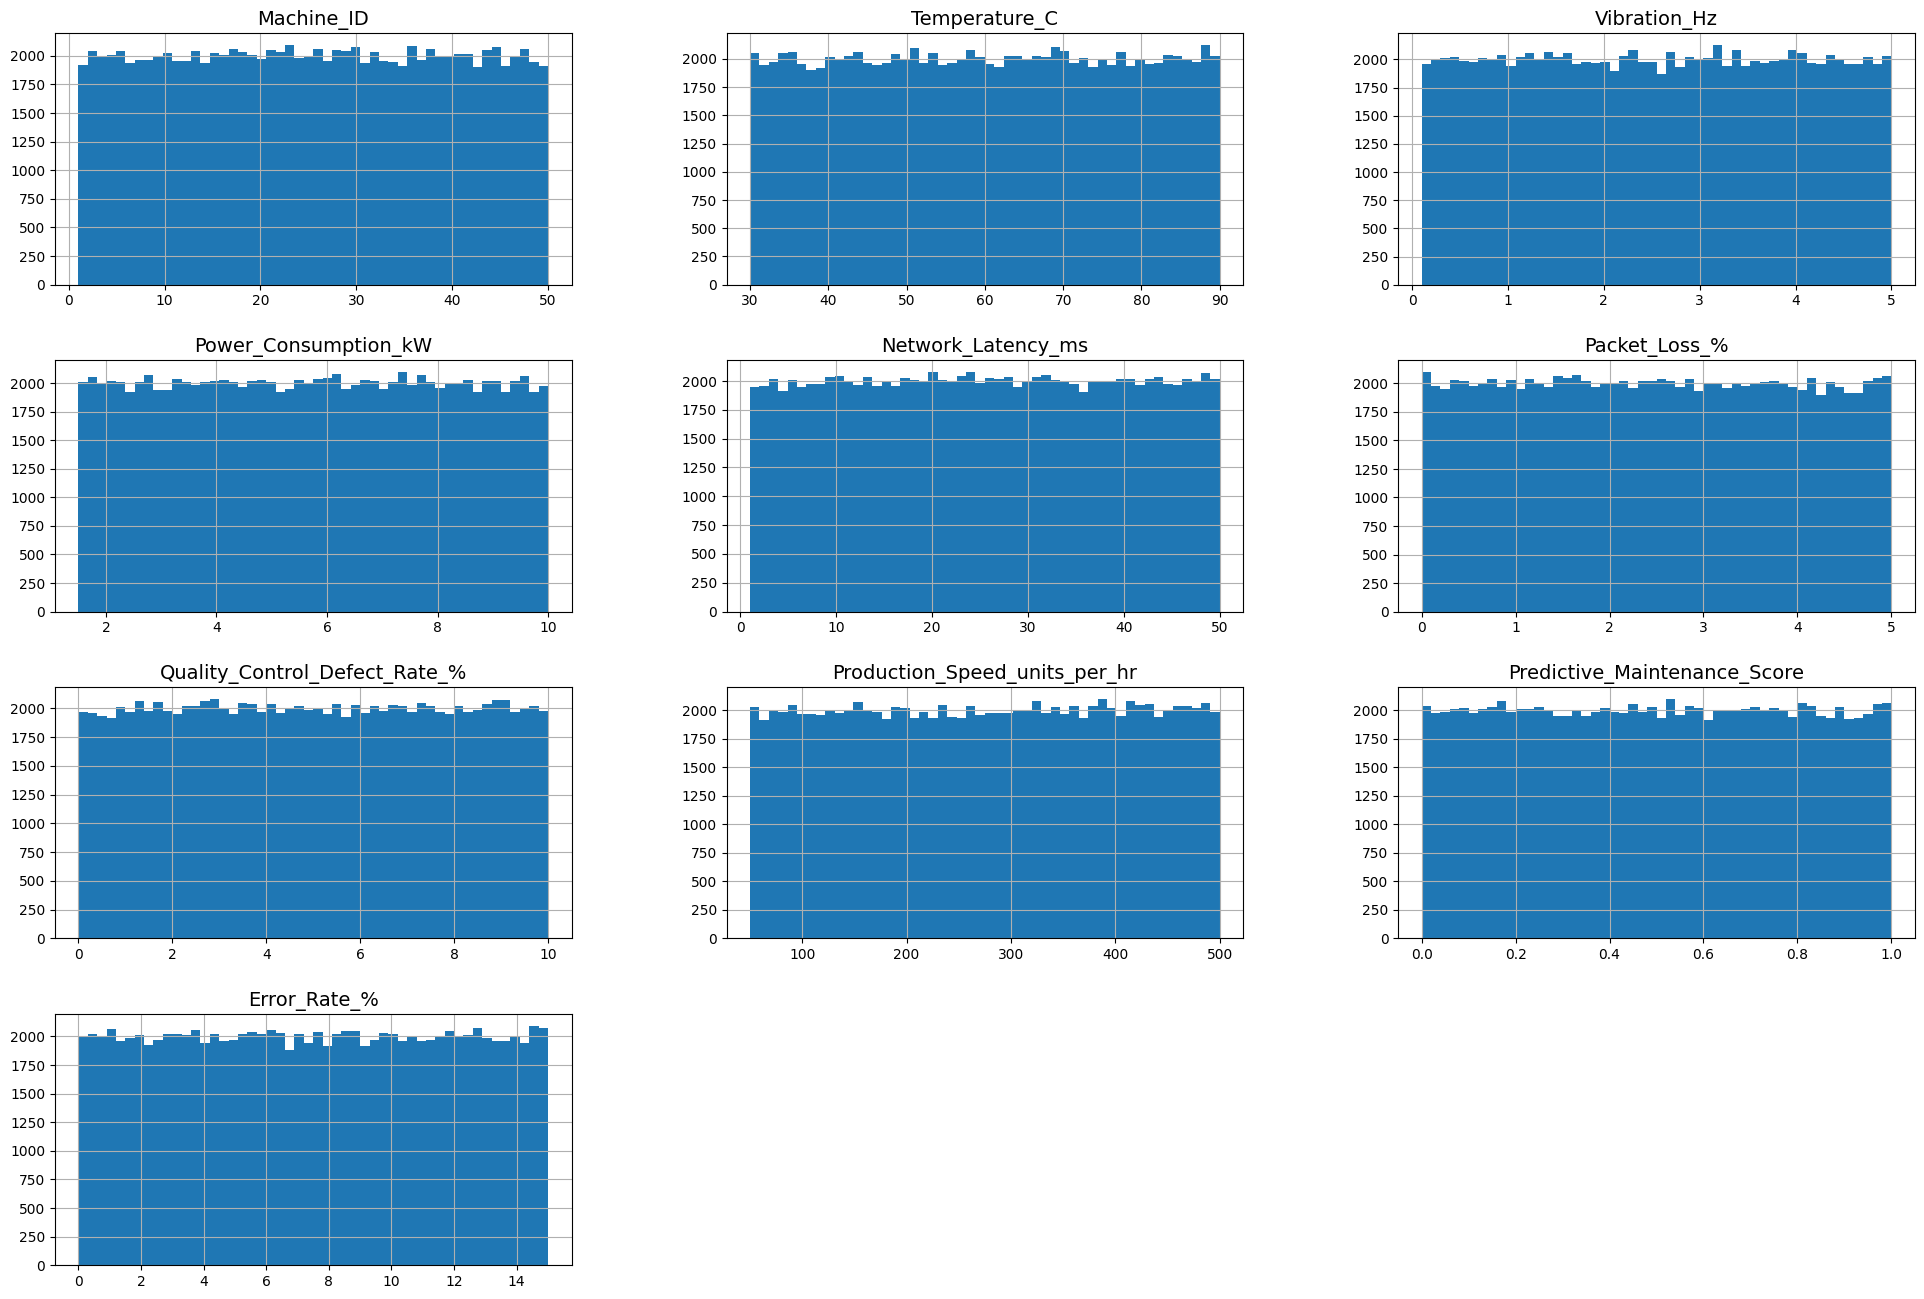

In [7]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Generate histograms for each numerical column in the housing DataFrame
manufacturing_data.hist(bins=50, figsize=(24, 16)) # Plot histograms with 50 bins and a figure size of 12x8 inches
#save_fig("attribute_histogram_plots")  # extra code
plt.show()

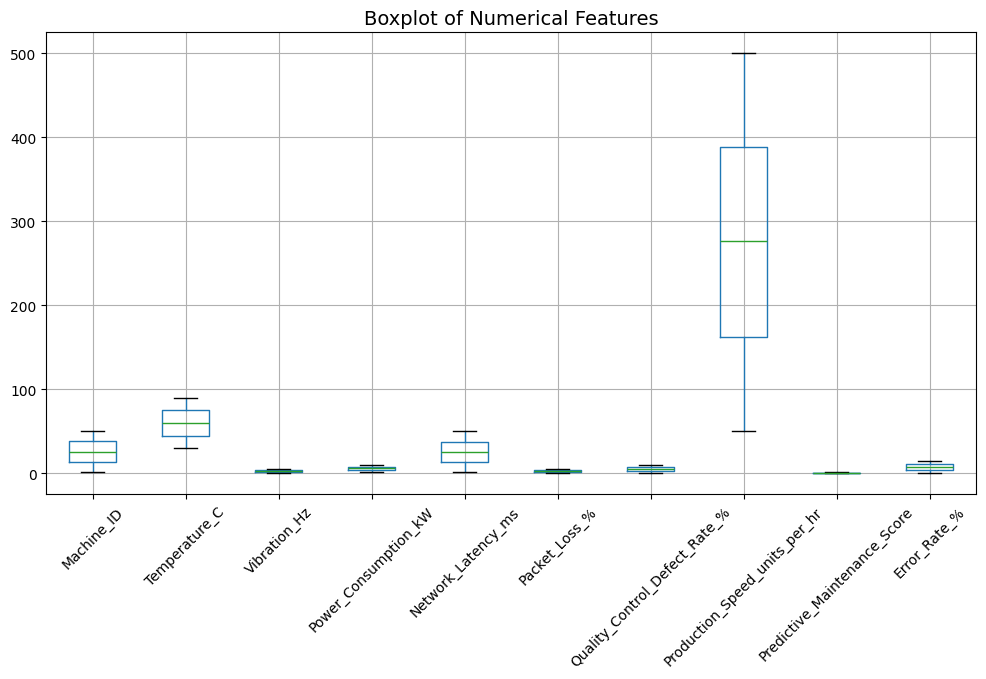

In [8]:
manufacturing_data.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from ipywidgets import interact
from matplotlib.lines import Line2D

numerical_cols = [
    'Temperature_C',
    'Vibration_Hz',
    'Power_Consumption_kW',
    'Network_Latency_ms',
    'Packet_Loss_%',
    'Quality_Control_Defect_Rate_%',
    'Production_Speed_units_per_hr',
    'Predictive_Maintenance_Score',
    'Error_Rate_%'
]

data_to_plot = manufacturing_data.copy()

# Define shared 3-color palette
shared_colors = ['#1f77b4', '#ffcc00', '#d62728']

# Append Efficiency_Status to the dropdown options
dropdown_options = numerical_cols + ['Efficiency_Status']

def plot_unified_matrix(target_col):
    plt.close('all')

    # Branch logic based on data type
    if target_col == 'Efficiency_Status':
        # Map categorical values
        unique_vals = data_to_plot[target_col].dropna().unique()
        color_map = dict(zip(unique_vals, shared_colors[:len(unique_vals)]))
        row_colors = data_to_plot[target_col].map(color_map)
    else:
        # Bin numerical values into 3 tiers
        binned_series = pd.qcut(
            data_to_plot[target_col],
            q=3,
            labels=['Low', 'Medium', 'High'],
            duplicates='drop'
        )
        color_map = {'Low': shared_colors[0], 'Medium': shared_colors[1], 'High': shared_colors[2]}
        row_colors = binned_series.map(color_map)

    # Generate scatter matrix
    sm = scatter_matrix(
        data_to_plot[numerical_cols],
        figsize=(18, 18),
        alpha=0.6,
        c=row_colors,
        diagonal='kde'
    )

    # Construct legend
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=12, label=label)
        for label, color in color_map.items()
    ]

    plt.legend(handles=legend_handles, title=target_col, loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=12)
    plt.suptitle(f"Scatter Matrix: Colored by {target_col}", y=1.02, fontsize=20)
    plt.show()

# Initialize widget
interact(plot_unified_matrix, target_col=dropdown_options);

interactive(children=(Dropdown(description='target_col', options=('Temperature_C', 'Vibration_Hz', 'Power_Cons…

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

# Get the unique categories (e.g., Low, Medium, High)
categories = manufacturing_data['Efficiency_Status'].dropna().unique()

def plot_conditional_heatmap(status):
    plt.close('all')

    # 1. Filter the dataset to ONLY include rows with the selected status
    filtered_data = manufacturing_data[manufacturing_data['Efficiency_Status'] == status]

    # 2. Calculate correlation for just this subset of data
    corr_matrix = filtered_data[numerical_cols].corr()

    # 3. Build the heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    cax = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    fig.colorbar(cax, shrink=0.8)

    ax.set_xticks(np.arange(len(numerical_cols)))
    ax.set_yticks(np.arange(len(numerical_cols)))
    ax.set_xticklabels(numerical_cols, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(numerical_cols, fontsize=10)

    # 4. Add the numbers
    for i in range(len(numerical_cols)):
        for j in range(len(numerical_cols)):
            val = corr_matrix.iloc[i, j]
            text_color = "white" if abs(val) > 0.6 else "black"
            ax.text(j, i, f"{val:.4f}", ha="center", va="center", color=text_color, fontsize=9)

    plt.title(f"Correlation Heatmap: When Efficiency is '{status}'", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

# Initialize the widget
interact(plot_conditional_heatmap, status=categories);

interactive(children=(Dropdown(description='status', options=('Low', 'Medium', 'High'), value='Low'), Output()…

### Verify Data integrity

In [11]:
print(manufacturing_data.isnull().sum())

Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
dtype: int64


##Split data

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X = manufacturing_data.drop(columns=['Efficiency_Status', 'Machine_ID', 'Timestamp'])
#X = manufacturing_data.drop(columns=['Efficiency_Status', 'Machine_ID', 'Timestamp', 'Production_Speed_units_per_hr', 'Error_Rate_%'])
#X = manufacturing_data.drop(columns=['Efficiency_Status', 'Operation_Mode', 'Machine_ID', 'Timestamp'])

y = manufacturing_data['Efficiency_Status']
#y = manufacturing_data['Operation_Mode']

X = pd.get_dummies(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Train models

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced')
}

#HAR LAGT TILL CLASS_WEIGHT, OBS!

# 2. Retrain the Tree models on the UN-SCALED data
print("Training Tree models...")
rf_model = models["Random Forest"]
rf_model.fit(X_train, y_train)

dt_model = models["Decision Tree"]
dt_model.fit(X_train, y_train)

# 3. Retrain the Linear model on the SCALED data
print("Training Logistic Regression...")
lr_scaled = models["Logistic Regression"]
lr_scaled.fit(X_train_scaled, y_train)

print("Training complete! Moving to evaluation...\n")

Training Tree models...
Training Logistic Regression...
Training complete! Moving to evaluation...



##Evaluering

=== Random Forest Evaluation ===
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       597
         Low       1.00      1.00      1.00     15565
      Medium       1.00      1.00      1.00      3838

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

ROC AUC Score (OVR): 1.0000



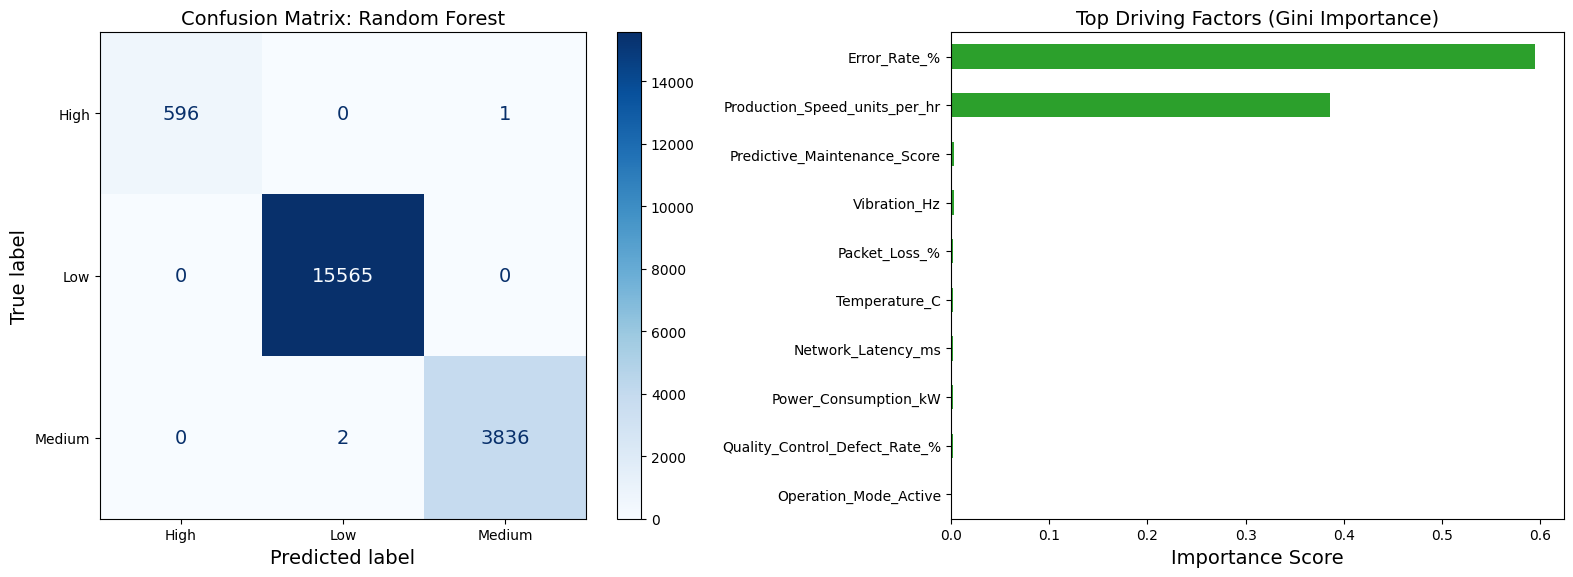

=== Scaled Logistic Regression Evaluation ===
              precision    recall  f1-score   support

        High       0.67      0.96      0.79       597
         Low       0.98      0.89      0.93     15565
      Medium       0.66      0.85      0.74      3838

    accuracy                           0.89     20000
   macro avg       0.77      0.90      0.82     20000
weighted avg       0.91      0.89      0.89     20000

ROC AUC Score (OVR): 0.9766



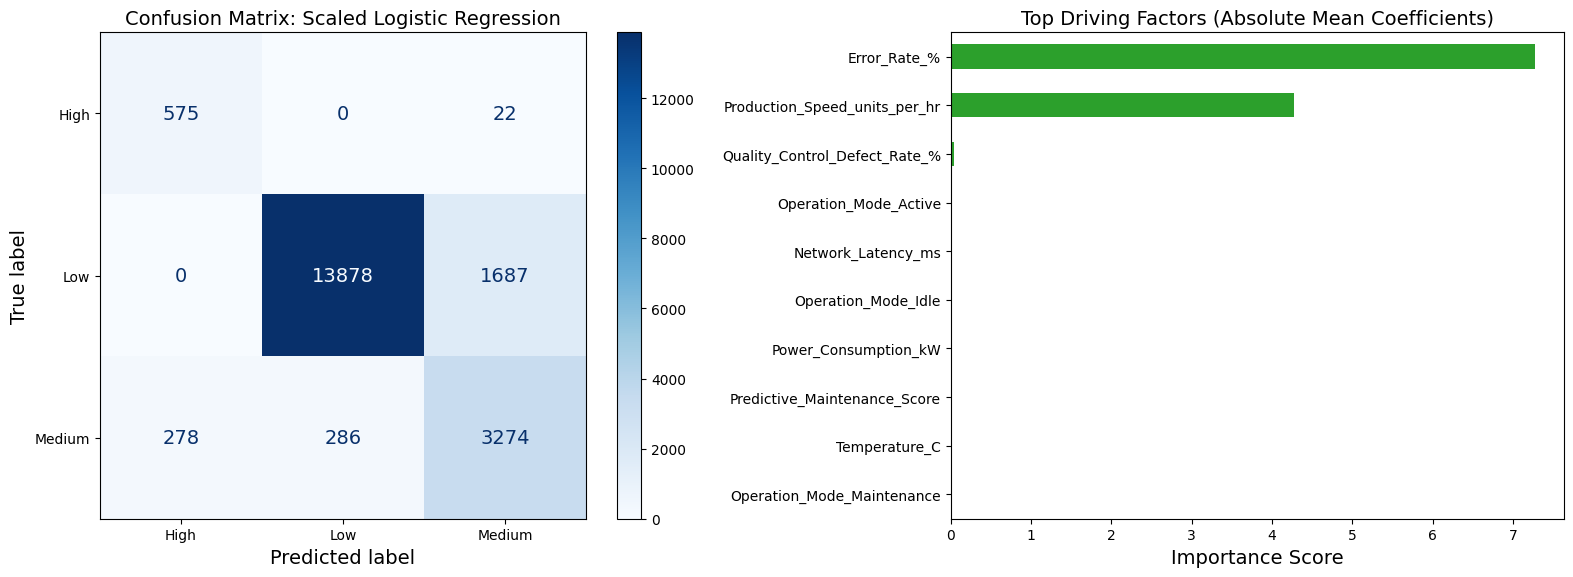

=== Decision Tree Evaluation ===
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       597
         Low       1.00      1.00      1.00     15565
      Medium       1.00      1.00      1.00      3838

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

ROC AUC Score (OVR): 0.9995



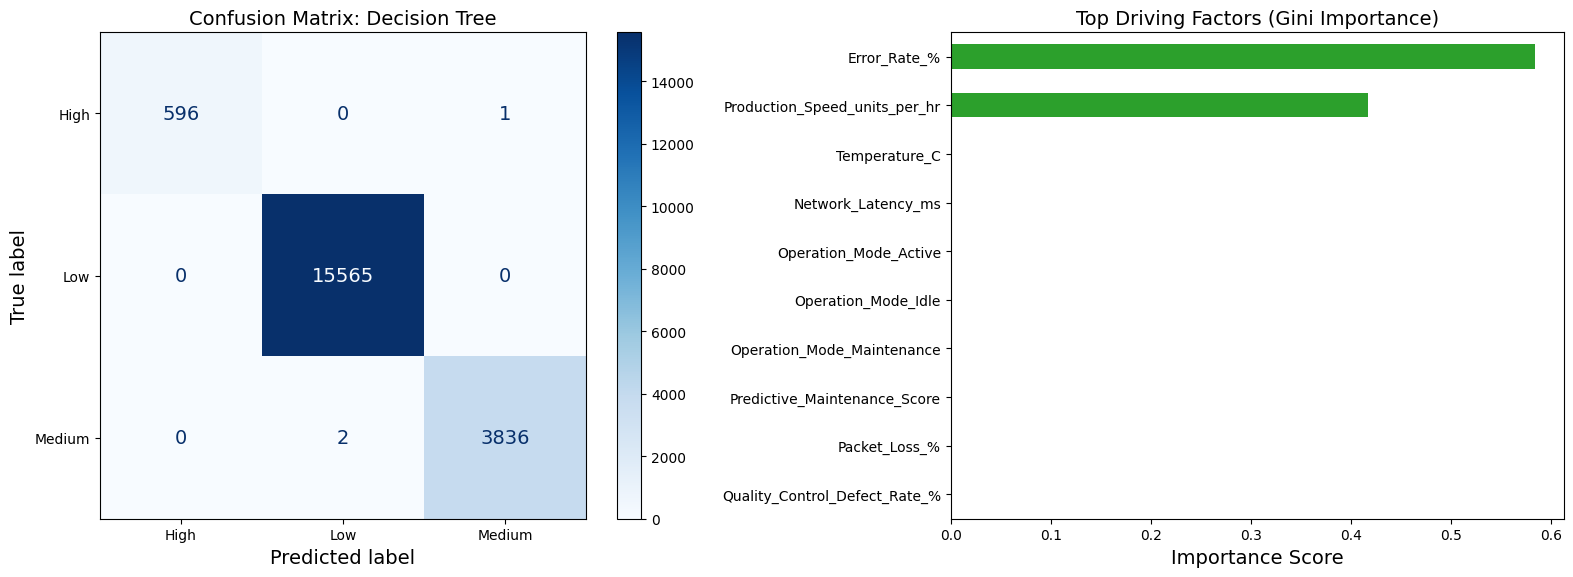

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

def evaluate_classification_model(model, X_test, y_test, feature_names, model_name="Model"):
    # Generate predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    print(f"=== {model_name} Evaluation ===")
    print(classification_report(y_test, y_pred, zero_division=0))

    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    print(f"ROC AUC Score (OVR): {roc_auc:.4f}\n")

    # Set up a 1x2 dashboard-style grid for the plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Plot 1: Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues', values_format='d', ax=axes[0])
    axes[0].set_title(f"Confusion Matrix: {model_name}", fontsize=14)

    # --- Plot 2: Main Influencing Factors ---
    importances = None
    title_suffix = ""

    # Check if the model is Tree-based (Random Forest, Decision Tree)
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        title_suffix = "(Gini Importance)"

    # Check if the model is Linear (Logistic Regression)
    elif hasattr(model, 'coef_'):
        # Logistic Regression returns a coefficient for each class.
        # We take the mean absolute value across all classes to find the overall driver.
        importances = np.mean(np.abs(model.coef_), axis=0)
        title_suffix = "(Absolute Mean Coefficients)"

    if importances is not None:
        # Bind the numbers to the column names, sort them, and grab the top 10
        feat_series = pd.Series(importances, index=feature_names).sort_values(ascending=True)
        top_features = feat_series.tail(10)

        # Draw the bar chart
        top_features.plot(kind='barh', ax=axes[1], color='#2ca02c') # Green bars for contrast
        axes[1].set_title(f"Top Driving Factors {title_suffix}", fontsize=14)
        axes[1].set_xlabel("Importance Score")
    else:
        # Fallback if a weird model is passed that doesn't support either
        axes[1].text(0.5, 0.5, 'Feature Importance Not Available', ha='center', va='center')
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()


# 1. Random Forest (Unscaled)
evaluate_classification_model(rf_model, X_test, y_test, X.columns, "Random Forest")

# 2. Logistic Regression (Scaled)
evaluate_classification_model(lr_scaled, X_test_scaled, y_test, X.columns, "Scaled Logistic Regression")

# 3. Decision Tree (Unscaled)
evaluate_classification_model(models["Decision Tree"], X_test, y_test, X.columns, "Decision Tree")

Denna tillagd för att kolla om vi är gravt overfitted eller om modellen faktiskt bara är för bra. Verkar som att när man balanserar vikten i low/medium/high så förutser modellen 100% med random forest.

<Axes: xlabel='Error_Rate_%', ylabel='Production_Speed_units_per_hr'>

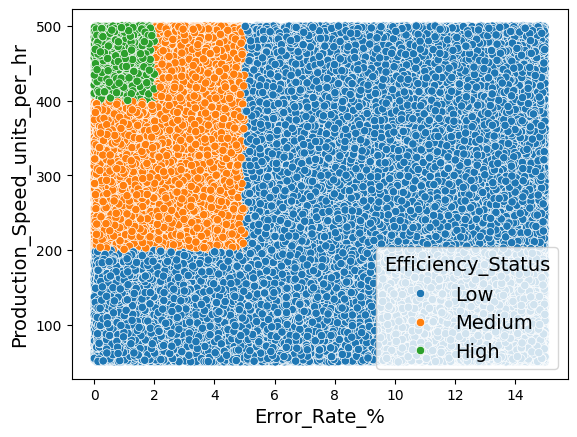

In [15]:
import seaborn as sns
sns.scatterplot(data=manufacturing_data, x="Error_Rate_%", y="Production_Speed_units_per_hr", hue="Efficiency_Status")

In [16]:
#Cross Validation delen
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
cval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [19]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import numpy as np

# ── Decision Tree ──────────────────────────────────────────────────────────────
dt_param_grid = {
    'max_depth':        [3, 5, 10, 15, None],
    'min_samples_split':[2, 10, 20, 50],
    'min_samples_leaf': [1, 4, 8, 16],
    'criterion':        ['gini', 'entropy']
}

dt_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_param_grid,
    cv=cval,                  # your StratifiedKFold
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
dt_search.fit(X_train, y_train)
print("Best DT params:", dt_search.best_params_)


# ── Random Forest ──────────────────────────────────────────────────────────────
rf_param_dist = {
    'n_estimators':     [200, 500, 1000],
    'max_depth':        [5, 10, 15, 20],
    'min_samples_split':[2, 10, 20],
    'min_samples_leaf': [4, 8, 16],       # most effective overfitting control
    'max_features':     ['sqrt', 'log2', 0.2, 0.4],
    'max_leaf_nodes':   [None, 50, 100, 200]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_param_dist,
    n_iter=30,              # tries 30 random combinations — increase if time allows
    cv=cval,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)


# ── Logistic Regression ────────────────────────────────────────────────────────
lr_param_grid = {
    'C':        [0.001, 0.01, 0.1, 1, 10, 100],   # inverse regularization strength
    'penalty':  ['l1', 'l2'],
    'solver':   ['liblinear', 'saga']              # both support l1 and l2
}

lr_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    lr_param_grid,
    cv=cval,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
lr_search.fit(X_train_scaled, y_train)   # LR uses scaled data
print("Best LR params:", lr_search.best_params_)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best DT params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF params: {'n_estimators': 1000, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_leaf_nodes': 100, 'max_features': 'log2', 'max_depth': 10}
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best LR params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


In [20]:
#EVALUERING
# ── Evaluation ─────────────────────────────────────────────────────────────────
models = {
    'Decision Tree':     (dt_search.best_estimator_, X_test),
    'Random Forest':     (rf_search.best_estimator_, X_test),
    'Logistic Regression':(lr_search.best_estimator_, X_test_scaled),
}

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    print(f"\n── {name} ──")
    print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))


── Decision Tree ──
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       597
      Medium       1.00      1.00      1.00     15565
        High       1.00      1.00      1.00      3838

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


── Random Forest ──
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       597
      Medium       1.00      1.00      1.00     15565
        High       1.00      1.00      1.00      3838

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


── Logistic Regression ──
              precision    recall  f1-score   support

         Low       0.86      0.82      0.84       597
      Medium       0.96      0.93      0.95     15565
      